**Previously on:** Lecture 38 built vocabulary (factor, level, factorial, interaction,
replication, randomization) and used it to reverse-engineer the 3D-printing dataset: a real,
useful, but confounded design -- `layer_height`/`print_velocity` tied together by construction,
`bed_temperature`/`fan_speed` correlated at exactly 1.0. Today: Quiz 8 on that material, a fresh
worked example on a dataset that gets the design *right*, and the whole-course synthesis pass.

Today's plan: quiz -> DOE worked example -> whole-course synthesis -> final-exam preview. This is
the last new-content day of the semester that isn't itself an assessment.

> Quiz 8 is administered in class; HW12 is due; final-exam practice problems (Modules 3-4 scope)
> go out at the end of class.

# Quiz 8, in class

Paper, closed-notes, about 10 minutes of writing plus logistics. Scoped exactly to Lecture 38:
identify factors/levels/responses from a short experiment description; compute the run count for a
stated full factorial; explain in one sentence why a screening (fractional) design might be chosen
over a full factorial when there are many factors; read a small printed design table and say what
experiment it specifies. No code demoed during the quiz -- instructor circulates for logistics
questions only.

# A design that gets it right

Recall Wednesday's number: the 3D-printing dataset's 9 factors, at their observed level counts,
would need over 1.2 million runs for a true full factorial. It shipped 50 -- a **screening
design**, not a full factorial, and two of its factor pairs paid for that with confounding. Today's
dataset is the opposite case: every combination really was run.

## Dataset: Ceramic Grinding Strength -- a real 2^5 factorial DOE

A complete, randomized 2^5 factorial experiment from NIST's Ceramics Division
(Said Jahanmir): 32 sintered reaction-bonded silicon nitride specimens ground
under every combination of 5 two-level factors (table speed, feed rate, wheel
grit, grinding direction, batch), with mean flexural strength as the response.
Coded `-1`/`+1` columns give the design matrix; matching physical-unit columns
(`table_speed_m_s`, `feed_rate_mm`, `wheel_grit`, `direction`, `batch`) give the
real levels. `run_order` is the actual randomized execution order (not the
design-matrix row order) -- correlation of strength with run_order is only
r=0.10, i.e. no meaningful time-drift confound, unlike a prior DOE candidate
this course tried and rejected for exactly that problem.

Source: NIST/SEMATECH e-Handbook of Statistical Methods, `CERAMIC.DAT`
(public domain, U.S. government work -- attribute as NIST/Said Jahanmir).
https://www.itl.nist.gov/div898/handbook/pri/section4/pri471.htm

In [1]:
import os
import pandas as pd

_file = 'ceramic_doe.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# set up features (coded factor levels) and target (strength)
x = data[['table_speed_coded', 'feed_rate_coded', 'wheel_grit_coded', 'direction_coded', 'batch_coded']]
y = data['strength']

print(f'{len(data)} runs, {x.shape[1]} factors (2^{x.shape[1]} full factorial), '
      f'strength range {y.min():.1f}-{y.max():.1f}')
data.head()

32 runs, 5 factors (2^5 full factorial), strength range 343.2-722.5


,run_order,table_speed_coded,table_speed_m_s,feed_rate_coded,feed_rate_mm,wheel_grit_coded,wheel_grit,direction_coded,direction,batch_coded,batch,strength
0,17,-1.0,0.025,-1.0,0.050,-1.0,140/170,-1.0,longitudinal,-1.0,1,680.45
1,30,1.0,0.125,-1.0,0.050,-1.0,140/170,-1.0,longitudinal,-1.0,1,722.48
2,14,-1.0,0.025,1.0,0.125,-1.0,140/170,-1.0,longitudinal,-1.0,1,702.14
3,8,1.0,0.125,1.0,0.125,-1.0,140/170,-1.0,longitudinal,-1.0,1,666.93
4,32,-1.0,0.025,-1.0,0.050,1.0,80/100,-1.0,longitudinal,-1.0,1,703.67


32 specimens, 5 two-level factors -- table speed, feed rate, wheel grit, grinding direction, batch
-- and `2**5 = 32`. Every possible combination is a row; this genuinely is a full factorial, not a
screening compromise. Check the two things Lecture 38 flagged as missing from the printing dataset:

In [2]:
import numpy as np
from scipy import stats

factors = ['table_speed_coded', 'feed_rate_coded', 'wheel_grit_coded', 'direction_coded', 'batch_coded']
print('corr(strength, run_order):', round(data['strength'].corr(data['run_order']), 3))
print()
print('pairwise correlation among the 5 coded factors:')
print(x.corr().round(3))

corr(strength, run_order): 0.104

pairwise correlation among the 5 coded factors:
                   table_speed_coded  feed_rate_coded  wheel_grit_coded  \
table_speed_coded                1.0             -0.0              -0.0   
feed_rate_coded                 -0.0              1.0              -0.0   
wheel_grit_coded                -0.0             -0.0               1.0   
direction_coded                 -0.0             -0.0               0.0   
batch_coded                      0.0             -0.0               0.0   

                   direction_coded  batch_coded  
table_speed_coded             -0.0          0.0  
feed_rate_coded               -0.0         -0.0  
wheel_grit_coded               0.0          0.0  
direction_coded                1.0          0.0  
batch_coded                    0.0          1.0  


`run_order` barely correlates with `strength` (r $\approx$ 0.10) -- randomized, no time-drift
confound. Every off-diagonal factor correlation is exactly 0 -- **orthogonal by construction**, the
opposite of `bed_temperature`/`fan_speed`'s r = 1.0. Same `lstsq` condition-number check Lecture 38
ran on the confounded pair, run here on this design instead:

In [3]:
X_design = np.column_stack([np.ones(len(data)), x.to_numpy()])
print('condition number, [1, 5 coded factors]:', round(np.linalg.cond(X_design), 6))

condition number, [1, 5 coded factors]: 1.0


1.0 -- as well-conditioned as a design matrix can be, the polar opposite of Wednesday's 5.9e17.
One more contrast with the printing dataset's 10-rows-per-level "replication that wasn't": check
how many times any single 5-factor combination repeats here.

In [4]:
print('runs per unique 5-factor combination:', data.groupby(factors).size().max())

runs per unique 5-factor combination: 1


Exactly 1 -- a genuine full factorial still has *zero* exact replicates. Orthogonality buys you
separable effects, not repeat measurements; a real replication study would still need to rerun some
conditions to isolate pure measurement noise. Now the main effects -- same recipe as Lecture 38's
ceramic bar chart, worth reading with real numbers this time:

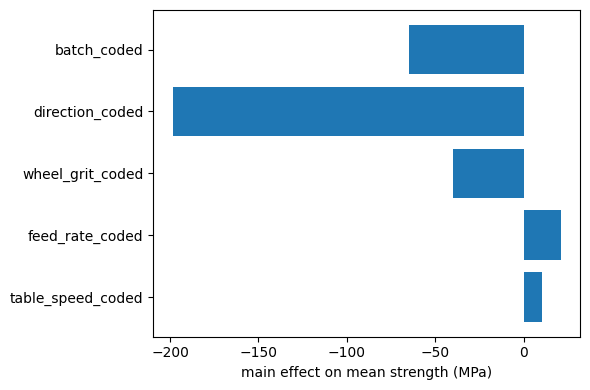

direction_coded       -198.47
batch_coded            -64.86
wheel_grit_coded       -39.79
feed_rate_coded         20.91
table_speed_coded       10.57


In [5]:
import matplotlib.pyplot as plt

effects = {f: data.loc[data[f] == 1, 'strength'].mean() - data.loc[data[f] == -1, 'strength'].mean()
           for f in factors}
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(effects.keys()), list(effects.values()))
ax.set_xlabel('main effect on mean strength (MPa)')
plt.tight_layout()
plt.show()
for f, e in sorted(effects.items(), key=lambda kv: -abs(kv[1])):
    print(f'{f:20s} {e:8.2f}')

`direction` dwarfs everything else (-198.5 MPa); `batch` is a distant second (-64.9). Test both the
same way Lecture 28 tested `material`:

In [6]:
for f in ['direction_coded', 'batch_coded']:
    g1, g2 = data.loc[data[f] == 1, 'strength'], data.loc[data[f] == -1, 'strength']
    t = stats.ttest_ind(g1, g2)
    print(f'{f:16s} diff={g1.mean() - g2.mean():8.2f}  p={t.pvalue:.5f}')

direction_coded  diff= -198.47  p=0.00000
batch_coded      diff=  -64.86  p=0.10308


`direction` is overwhelming (p $\approx$ 3e-12) -- grinding direction genuinely changes strength.
`batch` doesn't clear p < 0.05 at all (p $\approx$ 0.10): a real-looking 65 MPa gap that, on this
design's evidence, isn't distinguishable from noise. One interaction, read off the same orthogonal
structure -- does direction's effect depend on wheel grit?

In [7]:
inter = data['direction_coded'] * data['wheel_grit_coded']
g1, g2 = data.loc[inter == 1, 'strength'], data.loc[inter == -1, 'strength']
t_inter = stats.ttest_ind(g1, g2)
print(f'direction x wheel_grit interaction: diff={g1.mean() - g2.mean():.2f}  p={t_inter.pvalue:.5f}')

direction x wheel_grit interaction: diff=-19.87  p=0.62463


Not significant (p $\approx$ 0.62) -- no evidence the two factors interact; their effects appear
additive. Multiple-comparisons caveat from Lecture 38, applied for real: 5 main effects + 10
possible pairwise interactions is 15 tests. Bonferroni's corrected threshold is 0.05/15 $\approx$
0.0033. `direction` clears it easily; nothing else was ever close at the uncorrected 0.05 either --
a clean result, and cleanness is itself evidence of a well-designed experiment, not a coincidence.

# Course synthesis: one narrative pass

Every lecture this semester built one of six things you can now do with data. Walk the whole
semester in six rows, each with a callback to a real number you produced yourself:

| # | Competency | Where you built it | Callback |
|---|---|---|---|
| 1 | **Represent** data as arrays/tables | L1-3 (NumPy), L7 (lists/dicts), L8 (Pandas) | the elements table as your first structured dataset |
| 2 | **Summarize** data numerically & visually | L4-6, L9, L27 | thermal conductivity: z-score flagged 3 elements, the IQR fence flagged 6 |
| 3 | **Model** relationships in data | L19, L22-24 | Hall-Petch fit, k = 0.1106 MPa$\sqrt{\text{m}}$, R$^2$ = 0.94 |
| 4 | **Evaluate** whether a model is trustworthy | L20, L28 | infill pattern: p $\approx$ 0.95 (null); material: p $\approx$ 0.041 (real, borderline) |
| 5 | **Acquire** materials data responsibly | L32-34 | `usgs_hhi.csv`: DOI-cited, MIT-licensed, one typo (`'LI'` vs `'Li'`) caught in one line -- vs. `alloy_cleaning.csv`'s no-license, no-provenance gap |
| 6 | **Design** the next experiment | L38-39 | 3D printing's confounded pair (r = 1.0) vs. ceramic grinding's orthogonal design (`lstsq` condition number = 1.0) |

These aren't six separate courses of study -- they're one loop. Represent, summarize, model,
evaluate tell you *whether* to trust what you found; acquire and design tell you *what to go get
next*. Design feeds back into acquire, acquire feeds represent -- the scientific method, with
Python as the pen. One explicit boundary: no neural networks, no representation learning -- Lecture
26 stopped at "one more model type" (kNN) on purpose. MATSE 419 picks up from there.

# Final exam preview and wrap

No separate Midterm 3 this semester -- the final, during finals week, covers **Modules 3-4 only**
(Materials Project querying and phase diagrams, data ethics, digitizing/interpolation, figure
quality, and today's DOE) and is **not cumulative** back over Modules 1-2, already assessed by
Midterms 1 and 2. Practice problems mirror the quiz format: short answer, a design-table reading
question, one figure-critique question, and one design-a-study question -- the two AI-proof formats
the final actually uses. HW12 is due; Lectures 40-41 are dedicated review days, no new material.

**Take-home message:** of today's six-row table, only rows 5 and 6 -- acquire, design -- are fair
game on the final. Rows 1-4 already had their exam.